# Machine Learning Porject Final

In [43]:
# Libraries Downloaded
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight

import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print(" All libraries imported successfully.")


 All libraries imported successfully.


In [44]:
#Dataset Upload
from google.colab import files
uploaded = files.upload()
import pandas as pd
import numpy as np
df = pd.read_csv('synthetic_stroke_data.csv')

print("Dataset shape:", df.shape)
df.head(10)
print("=== Dataset Info ===")
df.info()
print("=== Statistical Summary ===")
df.describe()

Saving synthetic_stroke_data.csv to synthetic_stroke_data.csv
Dataset shape: (5110, 12)
=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
=== Statistical Summary ===


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [45]:
#Data Cleaning

# Check missing values
print("=== Missing Values Before Cleaning ===")
print(df.isnull().sum())
print()

# Check class imbalance
print("=== Target Distribution ===")
vc = df['stroke'].value_counts()
print(vc)
print(f"Stroke rate: {df['stroke'].mean()*100:.2f}%  ← Severe imbalance!")

# Drop the irrelevant 'id' column
df.drop(columns=['id'], inplace=True)
print(" Dropped 'id' column.")

# Remove the rare 'Other' gender rows
before = len(df)
df = df[df['gender'] != 'Other']
df.reset_index(drop=True, inplace=True)
print(f" Removed {before - len(df)} row(s) with gender='Other'.")

# Fill missing BMI with median (before any split to document the change)
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f" Filled {df['bmi'].isnull().sum()} BMI NaNs with median = {bmi_median:.1f}")

# Verify no missing values remain
print()
print("=== Missing Values After Cleaning ===")
print(df.isnull().sum())
print()
print(f" Data cleaned. Final shape: {df.shape}")


=== Missing Values Before Cleaning ===
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

=== Target Distribution ===
stroke
0    4861
1     249
Name: count, dtype: int64
Stroke rate: 4.87%  ← Severe imbalance!
 Dropped 'id' column.
 Removed 1 row(s) with gender='Other'.
 Filled 0 BMI NaNs with median = 28.1

=== Missing Values After Cleaning ===
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

 Data cleaned. Final shape: (5109, 11)


In [46]:
#Feature Engineering

# Create new feature: avg_glucose_level / bmi
df['glucose_bmi_ratio'] = df['avg_glucose_level'] / df['bmi']

print(" New feature 'glucose_bmi_ratio' created.")
print(df[['avg_glucose_level', 'bmi', 'glucose_bmi_ratio']].describe().round(2))

 New feature 'glucose_bmi_ratio' created.
       avg_glucose_level      bmi  glucose_bmi_ratio
count            5109.00  5109.00            5109.00
mean              106.14    28.86               3.86
std                45.29     7.70               1.71
min                55.12    10.30               0.62
25%                77.24    23.80               2.63
50%                91.88    28.10               3.43
75%               114.09    32.80               4.64
max               271.74    97.60              16.05


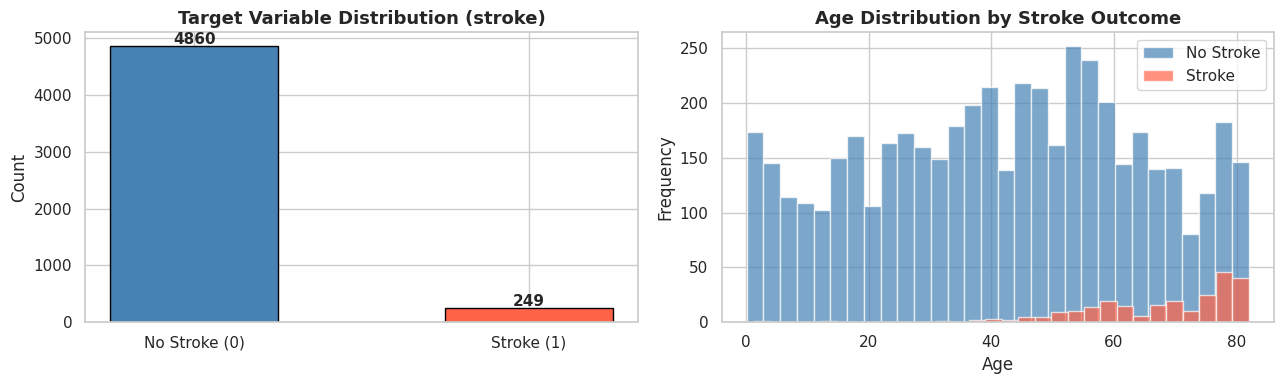

Plot 1: Count Plot — Target | Plot 2: Histogram — Age by Stroke


In [47]:
#EDA

#Plot 1: Target Distribution — Count Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['stroke'].value_counts()
labels = ['No Stroke (0)', 'Stroke (1)']
colors = ['steelblue', 'tomato']
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Variable Distribution (stroke)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 30, str(val),
                 ha='center', fontweight='bold', fontsize=11)

#Plot 2: Age Distribution (Histogram) — Univariate
axes[1].hist(df[df['stroke']==0]['age'], bins=30, alpha=0.7, color='steelblue', label='No Stroke', edgecolor='white')
axes[1].hist(df[df['stroke']==1]['age'], bins=30, alpha=0.7, color='tomato', label='Stroke', edgecolor='white')
axes[1].set_title('Age Distribution by Stroke Outcome', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Plot 1: Count Plot — Target | Plot 2: Histogram — Age by Stroke")


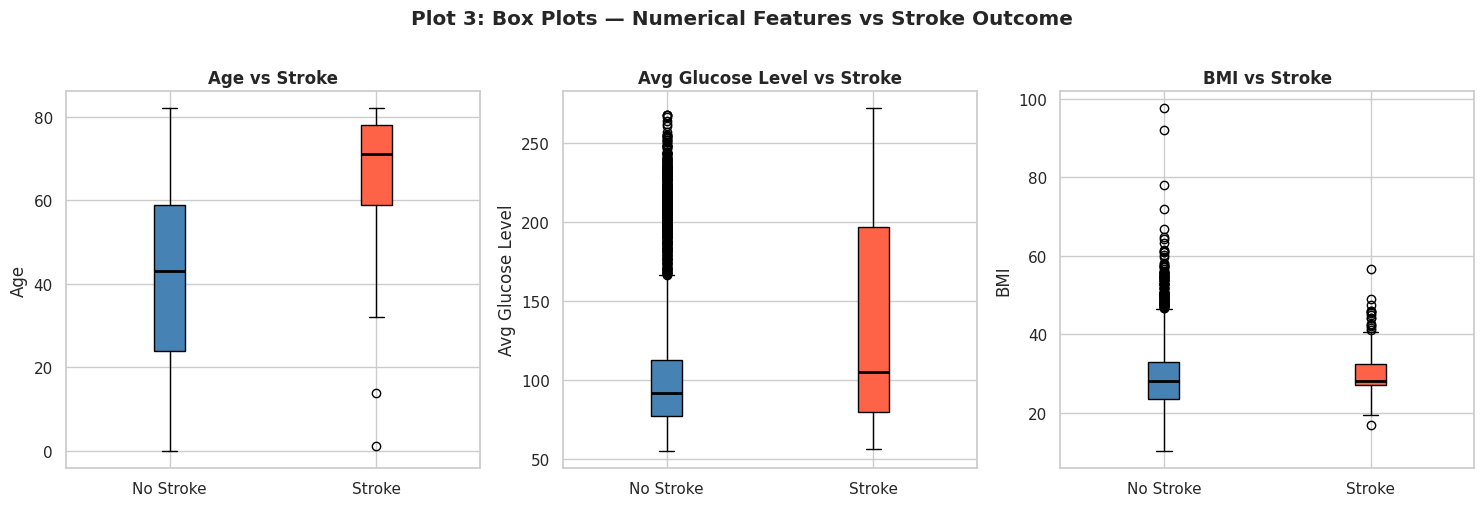

In [48]:
#Plot 3: Box Plots — Numerical features vs Stroke
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
num_features = ['age', 'avg_glucose_level', 'bmi']
titles = ['Age', 'Avg Glucose Level', 'BMI']

for ax, feat, title in zip(axes, num_features, titles):
    data_0 = df[df['stroke']==0][feat]
    data_1 = df[df['stroke']==1][feat]
    bp = ax.boxplot([data_0, data_1],
                    labels=['No Stroke', 'Stroke'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    ax.set_title(f'{title} vs Stroke', fontweight='bold')
    ax.set_ylabel(title)

plt.suptitle('Plot 3: Box Plots — Numerical Features vs Stroke Outcome', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

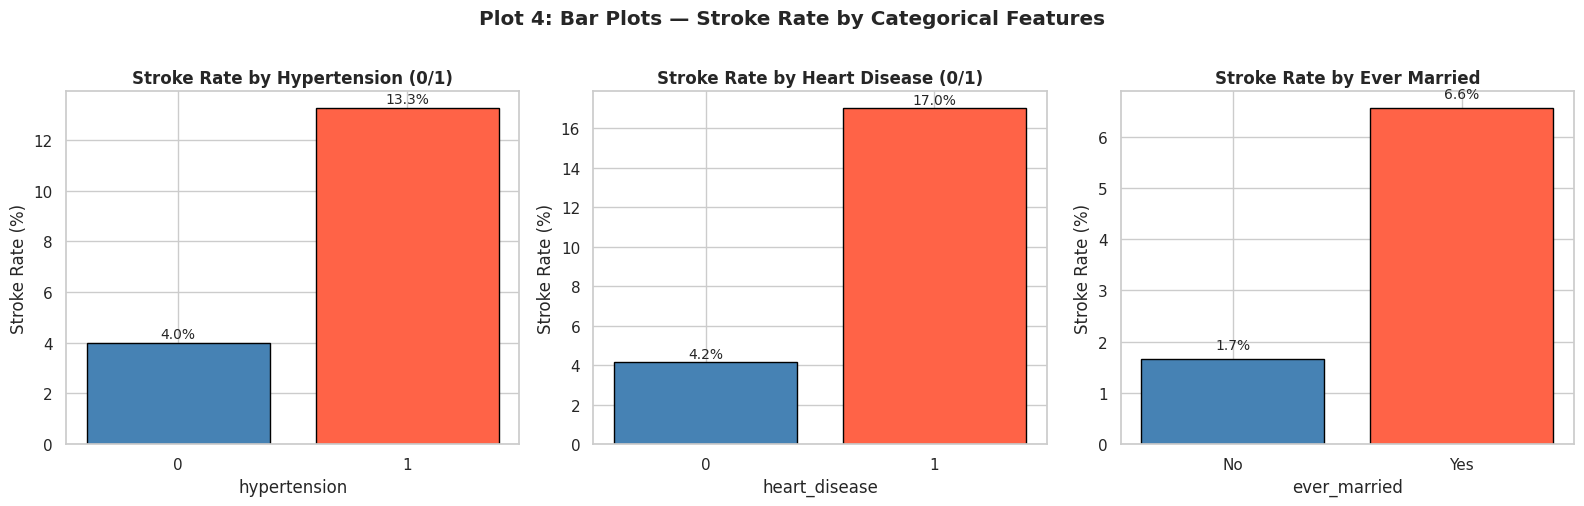

In [49]:
#Plot 4: Bar Plot — Categorical features vs Stroke Rate
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_features = ['hypertension', 'heart_disease', 'ever_married']
cat_labels   = ['Hypertension (0/1)', 'Heart Disease (0/1)', 'Ever Married']

for ax, feat, label in zip(axes, cat_features, cat_labels):
    stroke_rate = df.groupby(feat)['stroke'].mean() * 100
    colors_bar = ['steelblue'] * len(stroke_rate)
    colors_bar[-1] = 'tomato'
    bars = ax.bar(stroke_rate.index.astype(str), stroke_rate.values,
                  color=colors_bar, edgecolor='black')
    ax.set_title(f'Stroke Rate by {label}', fontweight='bold')
    ax.set_ylabel('Stroke Rate (%)')
    ax.set_xlabel(feat)
    for bar, val in zip(bars, stroke_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Plot 4: Bar Plots — Stroke Rate by Categorical Features', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

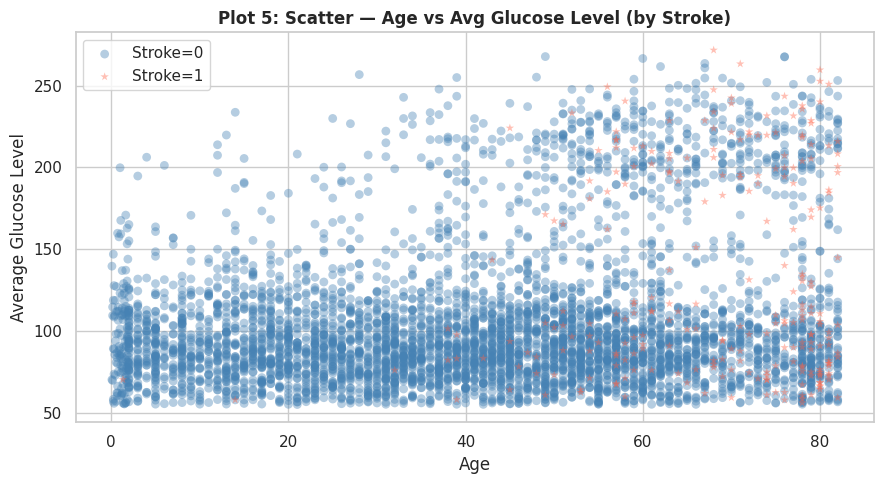

In [50]:
#Plot 5: Scatter Plot — Age vs Avg Glucose Level
plt.figure(figsize=(9, 5))
for label, color, marker in zip([0,1], ['steelblue','tomato'], ['o','*']):
    sub = df[df['stroke']==label]
    plt.scatter(sub['age'], sub['avg_glucose_level'],
                c=color, alpha=0.4, label=f'Stroke={label}',
                marker=marker, s=40, edgecolors='none')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.title('Plot 5: Scatter — Age vs Avg Glucose Level (by Stroke)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


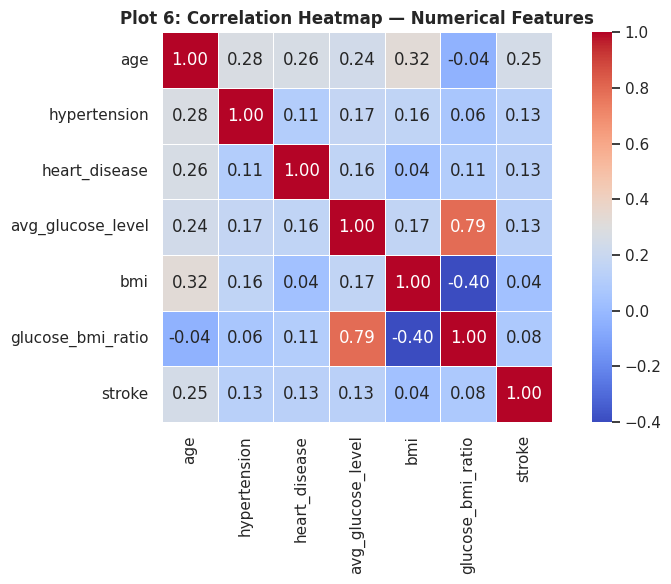

In [51]:
#Plot 6: Correlation Heatmap
plt.figure(figsize=(9, 6))
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level',
            'bmi', 'glucose_bmi_ratio', 'stroke']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Plot 6: Correlation Heatmap — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
#Statistical summary by group
print("=== Mean Values by Stroke Outcome ===")
summary = df.groupby('stroke')[['age','avg_glucose_level','bmi','glucose_bmi_ratio']].mean().round(2)
print(summary)

print()
print("=== Stroke Rate by Smoking Status ===")
print((df.groupby('smoking_status')['stroke'].mean()*100).round(2).rename('Stroke Rate (%)'))

print()
print("=== Stroke Rate by Work Type ===")
print((df.groupby('work_type')['stroke'].mean()*100).round(2).rename('Stroke Rate (%)'))

=== Mean Values by Stroke Outcome ===
          age  avg_glucose_level    bmi  glucose_bmi_ratio
stroke                                                    
0       41.97             104.79  28.80               3.83
1       67.73             132.54  30.09               4.44

=== Stroke Rate by Smoking Status ===
smoking_status
Unknown            3.04
formerly smoked    7.92
never smoked       4.76
smokes             5.32
Name: Stroke Rate (%), dtype: float64

=== Stroke Rate by Work Type ===
work_type
Govt_job         5.02
Never_worked     0.00
Private          5.10
Self-employed    7.94
children         0.29
Name: Stroke Rate (%), dtype: float64


In [53]:
#Encoding Categorial Features & Split Data

# Encode all categorical features with LabelEncoder
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_).tolist()))}")

print()
print("Feature dtypes after encoding:")
print(df.dtypes)

# Separate features and target
X = df.drop(columns=['stroke'])
y = df['stroke']

# Stratified split — essential for imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print()
print("Stroke rate in train:", y_train.mean().round(4))
print("Stroke rate in test :", y_test.mean().round(4))
print(" Stratified split preserves the class imbalance ratio.")

Encoded 'gender': {'Female': 0, 'Male': 1}
Encoded 'ever_married': {'No': 0, 'Yes': 1}
Encoded 'work_type': {'Govt_job': 0, 'Never_worked': 1, 'Private': 2, 'Self-employed': 3, 'children': 4}
Encoded 'Residence_type': {'Rural': 0, 'Urban': 1}
Encoded 'smoking_status': {'Unknown': 0, 'formerly smoked': 1, 'never smoked': 2, 'smokes': 3}

Feature dtypes after encoding:
gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
glucose_bmi_ratio    float64
dtype: object
Training samples : 4087
Test samples     : 1022

Stroke rate in train: 0.0487
Stroke rate in test : 0.0489
 Stratified split preserves the class imbalance ratio.


=== Feature Rankings (ANOVA F-test) ===
          Feature    F-Score      p-value
              age 258.342385 2.049258e-56
     hypertension  77.569745 1.860367e-18
avg_glucose_level  69.256678 1.165310e-16
    heart_disease  61.077152 6.931005e-15
     ever_married  47.509796 6.313109e-12
glucose_bmi_ratio  21.003548 4.721240e-06
              bmi   5.730098 1.672140e-02
        work_type   4.862723 2.749851e-02
   smoking_status   3.426537 6.422864e-02
   Residence_type   1.348294 2.456444e-01
           gender   0.483478 4.868906e-01


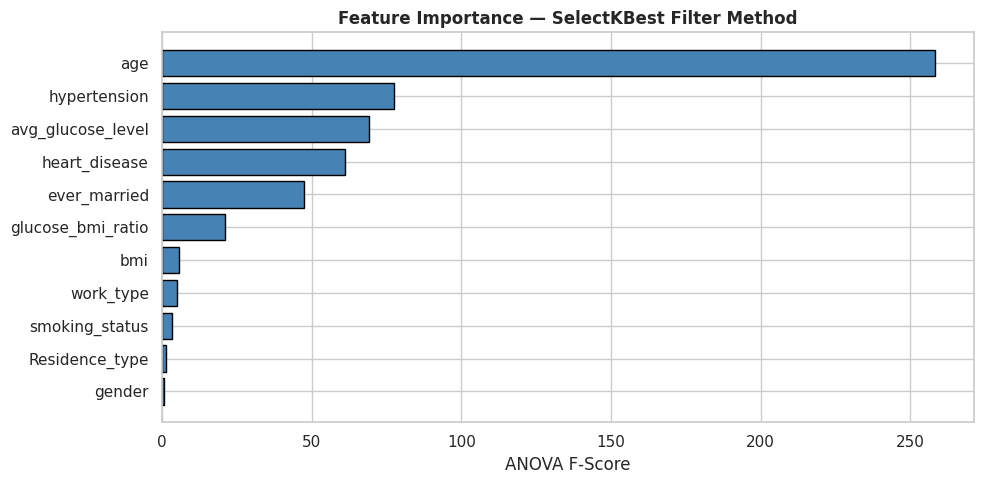


 Selected top 8 features: ['age', 'hypertension', 'avg_glucose_level', 'heart_disease', 'ever_married', 'glucose_bmi_ratio', 'bmi', 'work_type']
Shapes after feature selection: (4087, 8) (1022, 8)


In [54]:
#Features Selection

from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

feat_scores = pd.DataFrame({
    'Feature' : X.columns,
    'F-Score' : selector.scores_,
    'p-value' : selector.pvalues_
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print("=== Feature Rankings (ANOVA F-test) ===")
print(feat_scores.to_string(index=False))

# Visualise feature scores
plt.figure(figsize=(10, 5))
plt.barh(feat_scores['Feature'][::-1], feat_scores['F-Score'][::-1],
         color='steelblue', edgecolor='black')
plt.xlabel('ANOVA F-Score')
plt.title('Feature Importance — SelectKBest Filter Method', fontweight='bold')
plt.tight_layout()
plt.show()

# Keep top 8 features
TOP_K = 8
top_features = feat_scores['Feature'].head(TOP_K).tolist()
print(f"\n Selected top {TOP_K} features: {top_features}")

# Subset to top features
X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]
print("Shapes after feature selection:", X_train_sel.shape, X_test_sel.shape)


In [55]:
#Feature Scaling

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sel)
X_test_sc  = scaler.transform(X_test_sel)
print(" StandardScaler applied (fit on train, transform both sets).")


 StandardScaler applied (fit on train, transform both sets).


In [56]:
#Train And comparing the different Algorithms

def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  {'✅' if prec >= 0.3 else '❌ < 0.3'}")
    print(f"  Recall    : {rec:.4f}  {'✅' if rec >= 0.3 else '❌ < 0.3'}")
    print(f"  F1-Score  : {f1:.4f}")
    if auc is not None:
        print(f"  ROC-AUC   : {auc:.4f}")
    print()
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC': auc}

results = []


In [57]:
#Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]
results.append(evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob))

#Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sel, y_train)       # RF does not need scaling
rf_pred = rf.predict(X_test_sel)
rf_prob = rf.predict_proba(X_test_sel)[:, 1]
results.append(evaluate_model("Random Forest (100 trees)", y_test, rf_pred, rf_prob))

#Model 3: SVM — RBF Kernel
svm = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
svm.fit(X_train_sc, y_train)
svm_pred = svm.predict(X_test_sc)
svm_prob = svm.predict_proba(X_test_sc)[:, 1]
results.append(evaluate_model("SVM (RBF Kernel)", y_test, svm_pred, svm_prob))

# Comparison table
results_df = pd.DataFrame(results).set_index('Model')
print("=== Model Comparison Summary ===")
print(results_df.round(4).to_string())



  Logistic Regression
  Accuracy  : 0.7290
  Precision : 0.1303  ❌ < 0.3
  Recall    : 0.8000  ✅
  F1-Score  : 0.2241
  ROC-AUC   : 0.8386

  Random Forest (100 trees)
  Accuracy  : 0.9491
  Precision : 0.0000  ❌ < 0.3
  Recall    : 0.0000  ❌ < 0.3
  F1-Score  : 0.0000
  ROC-AUC   : 0.7735

  SVM (RBF Kernel)
  Accuracy  : 0.6898
  Precision : 0.1130  ❌ < 0.3
  Recall    : 0.7800  ✅
  F1-Score  : 0.1975
  ROC-AUC   : 0.7931

=== Model Comparison Summary ===
                           Accuracy  Precision  Recall      F1     AUC
Model                                                                 
Logistic Regression          0.7290     0.1303    0.80  0.2241  0.8386
Random Forest (100 trees)    0.9491     0.0000    0.00  0.0000  0.7735
SVM (RBF Kernel)             0.6898     0.1130    0.78  0.1975  0.7931


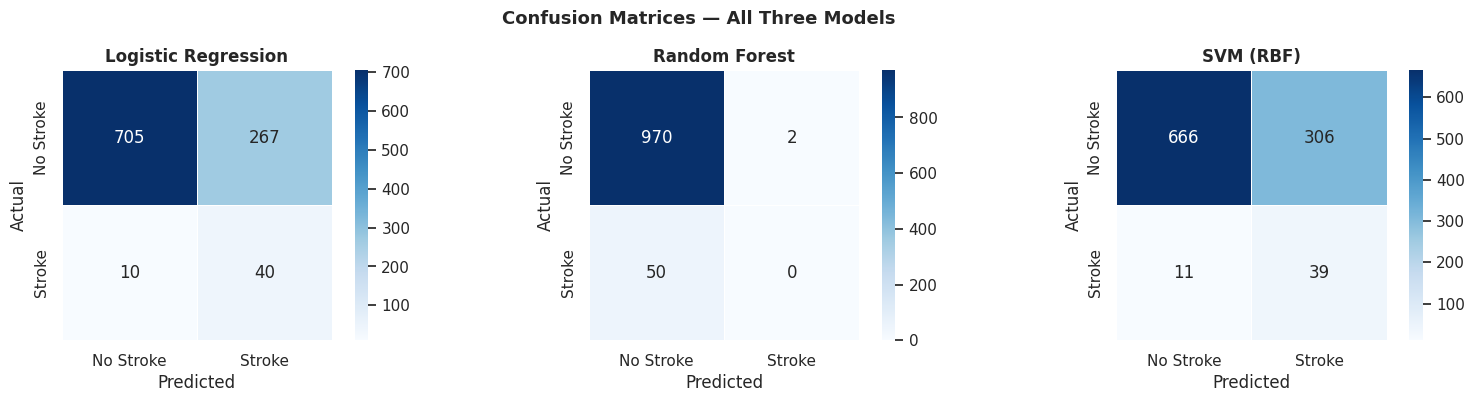

In [58]:
#Confusion Matrics

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_preds = [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("SVM (RBF)",           svm_pred),
]

for ax, (name, preds) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
                square=True, ax=ax,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Three Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


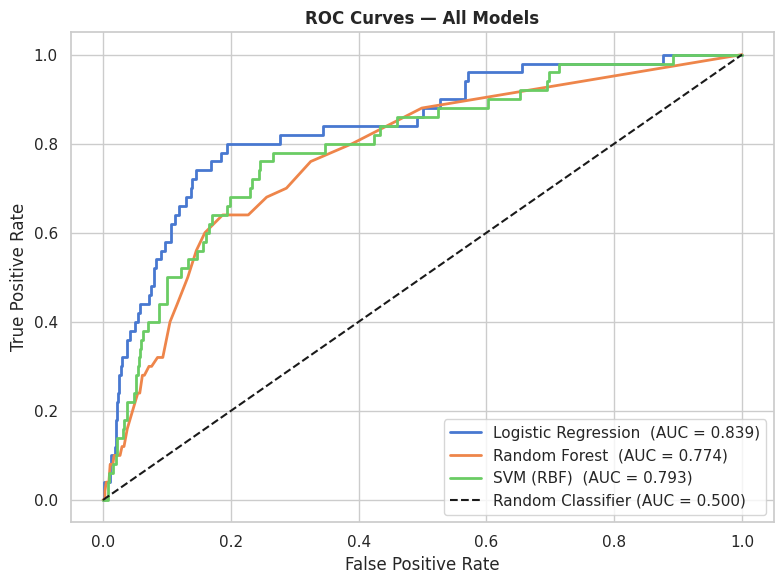

In [59]:
#ROC Curve

plt.figure(figsize=(8, 6))
model_probs = [
    ("Logistic Regression", lr_prob),
    ("Random Forest",       rf_prob),
    ("SVM (RBF)",           svm_prob),
]

for name, prob in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc_val:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [60]:
#Parameter Tuning

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid = param_grid,
    cv         = skf,
    scoring    = 'roc_auc',   # AUC is better than accuracy for imbalanced data
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_sel, y_train)

print("\n Best Parameters :", grid_search.best_params_)
print(f"   Best CV ROC-AUC  : {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test_sel)
best_prob = best_rf.predict_proba(X_test_sel)[:, 1]
tuned_result = evaluate_model("Tuned Random Forest ★", y_test, best_pred, best_prob)


Fitting 5 folds for each of 18 candidates, totalling 90 fits

 Best Parameters : {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 200}
   Best CV ROC-AUC  : 0.8248
  Tuned Random Forest ★
  Accuracy  : 0.7368
  Precision : 0.1288  ❌ < 0.3
  Recall    : 0.7600  ✅
  F1-Score  : 0.2203
  ROC-AUC   : 0.8244



In [61]:
#Validation

skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Accuracy CV
cv_acc = cross_val_score(best_rf, X[top_features], y,
                         cv=skf10, scoring='accuracy', n_jobs=-1)
# ROC-AUC CV
cv_auc = cross_val_score(best_rf, X[top_features], y,
                         cv=skf10, scoring='roc_auc', n_jobs=-1)
# Recall CV (important for medical: catching actual stroke cases)
cv_rec = cross_val_score(best_rf, X[top_features], y,
                         cv=skf10, scoring='recall', n_jobs=-1)

print("=== 10-Fold Stratified Cross-Validation — Tuned Random Forest ===")
print()
print(f"{'Fold':<6} {'Accuracy':>10} {'ROC-AUC':>10} {'Recall':>10}")
print("-" * 40)
for i, (a, u, r) in enumerate(zip(cv_acc, cv_auc, cv_rec), 1):
    print(f"  {i:<4} {a:>10.4f} {u:>10.4f} {r:>10.4f}")
print("-" * 40)
print(f"  Mean {cv_acc.mean():>9.4f} {cv_auc.mean():>10.4f} {cv_rec.mean():>10.4f}")
print(f"  Std  {cv_acc.std():>10.4f} {cv_auc.std():>10.4f} {cv_rec.std():>10.4f}")

=== 10-Fold Stratified Cross-Validation — Tuned Random Forest ===

Fold     Accuracy    ROC-AUC     Recall
----------------------------------------
  1        0.7886     0.8504     0.8000
  2        0.7593     0.8099     0.7200
  3        0.7397     0.8492     0.7600
  4        0.7613     0.8365     0.8000
  5        0.7710     0.8548     0.7600
  6        0.7299     0.8206     0.7200
  7        0.7554     0.8300     0.7200
  8        0.7495     0.8741     0.8800
  9        0.7476     0.8022     0.6400
  10       0.7588     0.8177     0.7083
----------------------------------------
  Mean    0.7561     0.8345     0.7508
  Std      0.0155     0.0214     0.0622


In [62]:
#Best Model Choosen
print("=== Classification Report — Tuned Random Forest ===")
print(classification_report(y_test, best_pred, target_names=['No Stroke', 'Stroke']))

prec_f = precision_score(y_test, best_pred, zero_division=0)
rec_f  = recall_score(y_test, best_pred, zero_division=0)
print(f"Precision : {prec_f:.4f}  {' yes >= 0.3' if prec_f >= 0.3 else 'no < 0.3'}")
print(f"Recall    : {rec_f:.4f}  {' yes >= 0.3' if rec_f >= 0.3 else 'no < 0.3'}")

=== Classification Report — Tuned Random Forest ===
              precision    recall  f1-score   support

   No Stroke       0.98      0.74      0.84       972
      Stroke       0.13      0.76      0.22        50

    accuracy                           0.74      1022
   macro avg       0.56      0.75      0.53      1022
weighted avg       0.94      0.74      0.81      1022

Precision : 0.1288  no < 0.3
Recall    : 0.7600   yes >= 0.3


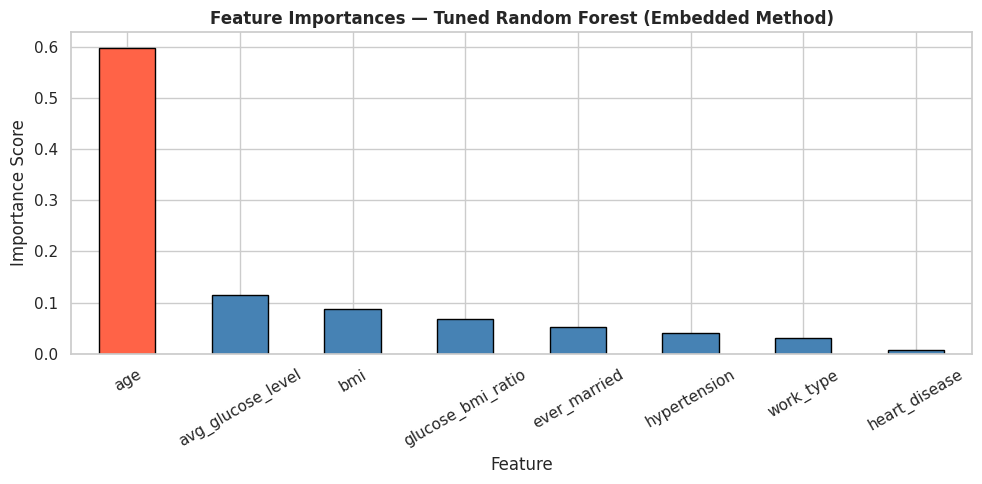

=== Feature Importance Ranking ===
age                  0.5985
avg_glucose_level    0.1154
bmi                  0.0883
glucose_bmi_ratio    0.0673
ever_married         0.0521
hypertension         0.0405
work_type            0.0300
heart_disease        0.0078


In [63]:
#Features Selection From Best Model

feat_imp = pd.Series(best_rf.feature_importances_, index=top_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['tomato' if i == 0 else 'steelblue' for i in range(len(feat_imp))]
feat_imp.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Feature Importances — Tuned Random Forest (Embedded Method)', fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("=== Feature Importance Ranking ===")
print(feat_imp.round(4).to_string())


In [64]:
#Saving the Model

joblib.dump(best_rf,'saved_model.pkl')
joblib.dump(scaler, 'saved_scaler.pkl')
joblib.dump(encoders,'saved_encoders.pkl')
joblib.dump(top_features,'saved_features.pkl')
print(" saved_model.pkl")
print(" saved_scaler.pkl")
print(" saved_encoders.pkl")
print("saved_features.pkl")

from google.colab import files
files.download('saved_model.pkl')
files.download('saved_scaler.pkl')
files.download('saved_encoders.pkl')
files.download('saved_features.pkl')


 saved_model.pkl
 saved_scaler.pkl
 saved_encoders.pkl
saved_features.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>